# Thumbs_Robot: Unitree G1 Three-Digit Hand-Gesture Control via PPO
## 專案導讀手冊與評分指南 (Notebook Handbook & Grading Guide)

本 Notebook 為 CSCN8020 強化學習期末專案的引導操作手冊。您可以直接在此 Notebook 中逐步執行代碼，完成從環境配置、模型審計、環境測試、模型訓練到結果可視化的完整流程。

### 專案大綱與小組簡介 (Project Overview & Team)
- **專案目標**：使用連續動作的 Actor-Critic (PPO 形式) 控制器，控制 Unitree G1 機器人的三指手部形態（包含兩個主手指與一個大拇指，即 3-digit hand），使其在 MuJoCo 模擬環境中能夠做出三種目標手勢的穩定、平滑且協調的控制：Thumbs Up、Open/Stop 以及 Thumbs Down。
- **學術亮點**：實作教授規定的**「數學 MDP $\rightarrow$ 演算法邏輯 $\rightarrow$ 程式變體 $\rightarrow$ 實時日誌」之四位一體精確對齊映射**。
- **小組成員**：Emmanuel • Liggia • Cemil • Chao

### 1. 環境安裝與設置步驟 (Environment Setup)
為確保本專案可在其他機器上完全再現，請依序執行以下單元格。這將會完成升級 pip、安裝依賴套件、拉取官方第三方 Unitree 倉庫，並驗證 Python 環境。

#### 第零步：升級 pip 並安裝 requirements.txt 中的依賴項目使用 WSL 開啟專案資料夾

1. 在 IDE 中按下 Ctrl + Shift + P（開啟命令面板）。
2. 輸入並選擇：WSL: Connect to WSL
3. 點選 Open Folder，選擇你在 WSL 裡的專案路徑(EX:/mnt/C/Final_Project)
4. 確認狀態：看 IDE 左下角的最下緣狀態列，是否變成了綠色或顯示 WSL: Ubuntu
5. Before installing MuJoCo or Unitree software, install the Linux packages required for Python virtual environments, C/C++ compilation, CMake/Ninja builds, OpenGL rendering, GLFW window management, and WSLg graphics.
```bash
sudo apt update && sudo apt install -y \
    python3-venv \
    python3-dev \
    build-essential \
    git \
    cmake \
    ninja-build \
    pkg-config \
    libglfw3 \
    libglfw3-dev \
    libgl1-mesa-dev \
    libegl1-mesa-dev \
    libxinerama-dev \
    libxcursor-dev \
    libxrandr-dev
```

6. Create a project-local virtual environment so this workshop does not interfere with other Python installations.

```bash
cd /mnt/c/Final_Project

python3 -m venv .venv
source .venv/bin/activate
```

7. 將當前環境註冊為 Jupyter 核心（這樣 IDE 才看得見）
```bash
python3 -m ipykernel install --user --name=my_kernel_name --display-name "Python (WSL Env)"
```

8. 在 IDE 中按下 Ctrl + Shift + P（開啟命令面板），，輸入並執行：Developer: Reload Window（重新載入視窗）

#### 第一步：升級 pip 並安裝 requirements.txt 中的依賴項目

In [1]:
!python -m pip install --upgrade pip setuptools wheel
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 818.2/818.2 kB 7.9 MB/s  0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 83.0.0
    Uninstalling setuptools-83.0.0:
      Successfully uninstalled setuptools-83.0.0


####  第二步：拉取官方第三方 Unitree MuJoCo 倉庫（若 external/unitree_mujoco 不存在）

In [35]:
import os
external_dir = os.path.join("external", "unitree_mujoco")
if not os.path.exists(external_dir):
    print("Cloning unitree_mujoco repository...")
    os.makedirs("external", exist_ok=True)
    !git clone https://github.com/unitreerobotics/unitree_mujoco.git {external_dir}
else:
    print(f"'{external_dir}' already exists, skipping clone.")

'external/unitree_mujoco' already exists, skipping clone.


#### 第三步：驗證主要庫是否安裝成功

In [54]:
import sys
print(f"Python Version: {sys.version}")
try:
    import mujoco
    print(f"MuJoCo Version: {mujoco.__version__}")
except ImportError:
    print("Error: MuJoCo is not installed.")
try:
    import torch
    print(f"PyTorch Version: {torch.__version__}")
    print(f"CUDA Available: {torch.cuda.is_available()}")
except ImportError:
    print("Error: PyTorch is not installed.")
try:
    import gymnasium as gym
    print(f"Gymnasium Version: {gym.__version__}")
except ImportError:
    print("Error: Gymnasium is not installed.")

Python Version: 3.12.3 (main, Jun 19 2026, 12:46:00) [GCC 13.3.0]
MuJoCo Version: 3.10.0
PyTorch Version: 2.13.0+cu130
CUDA Available: True
Gymnasium Version: 1.3.0


### 2. 模型關節審查與手勢角度校準 [Phase 0]
在開始強化學習之前，我們必須先生成 29-DOF 固定底座 G1 模型，並審查其手腕與手指 Actuators，手動校準出三種手勢的目標關節角度向量。
- **執行檔案**：[create_fixed_base_g1.py](./src/create_fixed_base_g1.py) 與 [g1_model_audit.py](./src/g1_rl/g1_model_audit.py)
- **任務**：載入 G1 機器人手部 XML 模型，印出所有關節（Joints）與致動器（Actuators）名稱與 Limits，手動校準並保存以下三種手勢的目標關節角度向量：
  1. **Thumbs Up (讚)**：大拇指伸展、兩指蜷縮、手腕朝上。
  2. **Open/Stop (掌心張開)**：三指完全伸展、掌心朝前。
  3. **Thumbs Down (倒讚)**：大拇指伸展、兩指蜷縮、手腕朝下。

> **三指形態約束 (3-Digit Hand Rule)**：Unitree G1 使用的是 **兩指主手指 + 一指大拇指** 的三指結構，絕不可使用 5 指人類手掌形態或渲染圖作為技術證據。

| 階段 (Phase) | 步驟名稱 | Arm & Wrist | 3 指關節狀態 (Finger Poses) | Success Criterion |
| :--- | :--- | :--- | :--- | :--- |
| 0. 初始狀態 | 保持 | 左臂水平伸直，手背朝外 (Pitch/Yaw 固定) | 握拳 (主指彎曲、拇指彎曲) | 關節穩定低於速度閾值 |
| 1. 豎大拇哥 | 讚 (Thumbs Up) | 保持水平，手背朝外 | 大拇指伸直，主指維持握拳 | 拇指關節角度達標 & 姿態穩定 |
| 2. 張開手掌 | 開掌 (Open/Stop) | 保持水平，手掌朝前/朝外 | 大拇指 + 2 根主指全部張開 | 3 指關節角度均達張開閾值 |
| 3. 回復握拳 | 握拳 | 保持水平，手背朝外 | 3 指全部收回握拳 | 恢復初始握拳角度 |
| 4. 翻轉倒讚 | 倒讚 (Thumbs Down) | 手腕旋轉 180°（手背朝內/朝前，拇指朝下） | 大拇指伸直（朝下），主指維持握拳 | 手腕旋轉角度達標 & 拇指朝下 |
| 5. 重置復原 | 重置/循環 | 手腕旋轉回原位（手背朝外） | 3 指全部張開 (回到步驟 3 開掌) | 手腕與手指恢復至 Phase 2 狀態 |

In [55]:
# 生成固定底座的 G1 模型並執行模型審計
!python src/create_fixed_base_g1.py

!python src/g1_rl/g1_model_audit.py --xml-path assets/g1_fixed_base/scene_29dof_fixed_base.xml --no-viewer

Removed free joint: floating_base_joint
Created fixed-base model: assets/g1_fixed_base/g1_29dof_fixed_base.xml
Copied meshes to: assets/g1_fixed_base/meshes
Created fixed-base scene: assets/g1_fixed_base/scene_29dof_fixed_base.xml

Fixed-base G1 assets created successfully.
Loading Unitree G1 Model from: assets/g1_fixed_base/scene_29dof_fixed_base.xml

--- Joint Audit ---
Total degrees of freedom (nv): 32
Total number of joints (njnt): 32
Joint ID 00 | Name: 'left_hip_pitch_joint' | Type ID: 3 | Limits: [-2.5307  2.8798]
Joint ID 01 | Name: 'left_hip_roll_joint' | Type ID: 3 | Limits: [-0.5236  2.9671]
Joint ID 02 | Name: 'left_hip_yaw_joint' | Type ID: 3 | Limits: [-2.7576  2.7576]
Joint ID 03 | Name: 'left_knee_joint' | Type ID: 3 | Limits: [-0.087267  2.8798  ]
Joint ID 04 | Name: 'left_ankle_pitch_joint' | Type ID: 3 | Limits: [-0.87267  0.5236 ]
Joint ID 05 | Name: 'left_ankle_roll_joint' | Type ID: 3 | Limits: [-0.2618  0.2618]
Joint ID 06 | Name: 'right_hip_pitch_joint' | Type I

### 3. Gymnasium 環境開發與隨機動作測試 [Phase 1]
- **執行檔案**：[g1_hand_env.py](./src/g1_rl/g1_hand_env.py)
- **任務**：
  * 定義連續狀態空間 $s_t$：$s_t = [q_t, \dot{q}_t, q_{\text{target}}(g), q_{\text{target}}(g)-q_t, \text{one\_hot}(g), a_{t-1}]$
  * 定義連續動作空間 $a_t$：控制關節（手腕與手指）的角度增量。
  * 實作複合獎勵函數：
    $$r_t = w_p(e_{t-1} - e_t) - w_h E_{\text{hand}} - w_o E_{\text{orientation}} - w_v \|\dot{q}_t\|^2 - w_a \|a_t\|^2 - w_s \|a_t-a_{t-1}\|_2^2 + b_{\text{hold}} I_{\text{hold}} - c_{\text{time}}$$

    其中姿態加權誤差 $e_t$ 定義為：

    $$e_t = w_{\text{wrist}} \Vert{}q_t^{\text{wrist}} - q_{\text{target}}^{\text{wrist}}\Vert{}_2 + w_{\text{finger}} \Vert{}q_t^{\text{finger}} - q_{\text{target}}^{\text{finger}}\Vert{}_2$$

  * 實作維持手勢成功判定（Hold 檢測機制，例如當關節姿態誤差與方向誤差小於閾值並維持 15 步以上，判定為成功完成）。

請執行下方的隨機動作測試單元格，驗證 [g1_hand_env.py](./src/g1_rl/g1_hand_env.py) 的 Gymnasium 封裝是否工作正常：

In [56]:
# 測試 Gymnasium 環境是否能正常初始化與執行 step（隨機動作冒煙測試）
import os
import sys
sys.path.append(os.path.abspath("src"))
from g1_rl.g1_hand_env import G1HandEnv

try:
    # 實例化環境，若 assets/g1_hand.xml 還在開發中，這裏主要作為 API 測試
    env = G1HandEnv(xml_path="assets/g1_fixed_base/scene_29dof_fixed_base.xml")
    obs, info = env.reset()
    print("SUCCESS: Environment initialized successfully!")
    print(f"Observation Space Shape: {obs.shape}")
    print(f"Action Space Shape: {env.action_space.shape}")
    print(f"Initial target gesture: {info.get('target_gesture')}")
    
    # 隨機執行 1 個 Step
    action = env.action_space.sample()
    next_obs, reward, terminated, truncated, step_info = env.step(action)
    print("SUCCESS: Environment stepped successfully!")
    print(f"Step Reward: {reward}")
    print(f"Next Obs Shape: {next_obs.shape}")
    print(f"Reward info components: {step_info.get('reward_info')}")
except Exception as e:
    print("Environment test failed. (This is normal if xml model or logic is in placeholder status)")
    print("Error details:", e)

SUCCESS: Environment initialized successfully!
Observation Space Shape: (32,)
Action Space Shape: (5,)
Initial target gesture: THUMBS_UP
SUCCESS: Environment stepped successfully!
Step Reward: -3.5176886916160583
Next Obs Shape: (32,)
Reward info components: {'reward_total': -3.5176886916160583, 'progress': 0.0, 'pose_error_penalty': -1.0305132865905762, 'orientation_penalty': -1.1999374628067017, 'smoothness_penalty': -3.134493112564087, 'smoothness_delta_penalty': -0.0, 'joint_limit_penalty': -0.0, 'hold_bonus': 0.0, 'success_bonus': 0.0, 'time_penalty': -0.1}


### 4. PPO 演算法架構與網路設計 [Phase 2]
- **執行檔案**：[actor_critic_network.py](./src/Thumbs_Robot/actor_critic_network.py)、[rollout_buffer.py](./src/Thumbs_Robot/rollout_buffer.py)、[agent.py](./src/Thumbs_Robot/agent.py)

* 專案流程圖


```text

======================= 階段一：Rollout 收集 (On-Policy 採樣與環境互動) =======================
當前狀態 s_t (包含關節狀態、目標手勢、前一步動作 a_{t-1})
  │
  ├────────────────────────────────────────────────┐
  ▼ (Actor 網路)                             ▼ (Critic 網路)
均值 μ_θ(s_t) 與標準差 σ_θ(s_t)               狀態價值估計 V_ϕ(s_t)
  │                                               │
  ▼ (高斯分佈採樣)                                 │
連續動作 a_raw ~ N(μ_θ, σ_θ)                       │
  │                                               │
  ▼ (動作安全極限剪裁)                              │
安全動作 a_t = clip(a_raw, a_min, a_max)           │
  │                                               │
  ▼ (施加動作至 MuJoCo 模擬器環境)                  │
計算平滑度懲罰與維持獎勵，獲得總獎勵 r_t              │
獲得下一狀態 s_{t+1} 與 terminated/truncated        │
  │                                               │
  ▼                                               ▼
將 (s_t, a_t, r_t, log_prob_old, V_ϕ(s_t), terminated, truncated) 存入 Buffer
                                (持續累積收集 N 步)

======================= 階段二：優勢估計與 Bootstrap 處理 =======================
從 Rollout Buffer 讀取整段軌跡數據 (States, Unclipped_Actions, Rewards, Masks...)
  │
  ▼ (Bootstrapping 處理)
計算末端狀態價值 V_ϕ(s_{N+1})：
  ├── 若 terminated = True  ──> Mask = 0，不進行未來的價值累加
  └── 若 truncated = True   ──> Mask = 1，使用 V_ϕ(s_{N+1}) 進行 Bootstrap 補充
  │
  ▼ (廣義優勢估計 GAE-λ)
計算 A_t (GAE) 與 回報目標 R_t = A_t + V_ϕ(s_t)

======================= 階段三：PPO 策略與價值網路更新 (當 Buffer 存滿時) =======================
打亂數據，拆分為多個 Mini-batch (進行 K 個 Epoch 更新)
  │
  ├────────────────────────────────────────┐
  ▼ (當前 Actor 網路)                       ▼ (當前 Critic 網路)
計算新 log_prob 與策略熵 H(π_θ)            預測新價值 V_ϕ(s_t)
  │                                        │
  ▼ (計算概率比率 r_t)                      │
r_t = exp(log_prob(a_raw) - log_prob_old(a_raw))
  │                                        │
  ▼ (優勢 Mini-batch 標準化)                │
A_norm = (A_batch - mean) / (std + 1e-8)   │
  │                                        │
  ├────────────────────────────────────────┼────────────────────────────────────────┐
  ▼ (Actor 損失計算)                        ▼ (Critic 損失計算)                      ▼ (策略熵正則)
L_actor = -min(ρ_t*A_norm,                 L_critic = (R_t - V_ϕ(s_t))²             H(π_θ)
               clip(ρ_t, 1-ε, 1+ε)*A_norm)
  │                                        │                                         │
  └───────────────────────────────────────┬─┴────────────────────────────────────────┘
                                          ▼
                          計算總體損失 (Total Loss)
                          L_total = L_actor + c₁*L_critic - c₂*H(π_θ)
                                          │
                                          ▼
                              反向傳播 (Backpropagation)
                                          │
                                          ▼ (梯度安全剪裁)
                              梯度剪裁 (L2 Norm Clipping)
                                          │
                                          ▼
                              更新 Actor (θ) 與 Critic (ϕ) 參數

======================= 階段四：診斷日誌與監控 (Diagnostics) =======================
計算並記錄以下指標至 Console / CSV / TensorBoard：
- 策略散度 (approx_kl)
- 價值預測解釋變異量 (explained_variance)
- 策略平均標準差 (mean_actor_std)
- 各項損失函數組件 (actor_loss, critic_loss, entropy)

```

- **下表展示了數學公式、演算法邏輯、程式碼變數與實時日誌的對應關係**

| 數學概念 (MDP Formula) | 演算法邏輯 (Algorithm Logic) | 程式碼變數 (Code Variable) | Console / CSV 日誌欄位 (Log Field) |
| :--- | :--- | :--- | :--- |
| **當前狀態** $s_t$ | 接收環境物理與任務觀測向量 | `obs` / `state` | `pose_error`, `orientation_error` |
| **動作分佈** $\pi_\theta(a \mid s_t)$ | Actor 網路預測的高斯均值與標準差 | `dist.mean` / `dist.stddev` | `actor_mean`, `actor_std` |
| **採樣動作** $a_{raw}$ | 從高斯分佈中隨機採樣探索 | `raw_action` / `action_unclipped` | `action_sample` |
| **安全動作** $a_t$ | 將採樣動作剪裁至物理安全邊界 | `clipped_action` | `action_clipped` |
| **平滑度懲罰** $r_{smooth}$ | 懲罰相鄰動作的平方差以消除抖動 | `r_smooth` / `r_smooth_delta` | `smoothness_penalty`, `smoothness_delta_penalty` |
| **總即時獎勵** $r_t$ | 多目標合成獎勵（姿態+維持+平滑） | `reward` / `total_reward` | `reward` / `reward_total` |
| **狀態價值** $V_\phi(s_t)$ | Critic 網路預測的當前期望回報 | `value` / `value_t` | `value` / `V(s_t)` |
| **Bootstrap 估計** $V(s_{t+1})$ | 下一狀態的價值預估 (區分時間截斷) | `next_value` / `next_val` | `next_value` |
| **回報目標** $R_t$ (TD Target) | 貝爾曼目標值估算 (GAE 加價值) | `returns` / `td_tgt` | `td_target` |
| **優勢估計** $A_t$ | 經過 Mini-batch 標準化後的優勢信號 | `advantages` / `adv` | `advantage` |
| **概率比率** $\rho_t(\theta)$ | 新舊策略重要性採樣比率 | `ratio` | `clip_fraction` (裁剪比例監控) |
| **策略散度** $KL(\pi_{\theta_{old}} \| \pi_\theta)$ | 監控新舊策略在更新過程中的 KL 散度 | `approx_kl` | `approx_kl`  |
| **策略損失** $L_{\text{actor}}$ | PPO Clipped Surrogate 損失 | `actor_loss` | `actor_loss` |
| **價值損失** $L_{\text{critic}}$ | 價值網路的均方誤差 (MSE) 損失 | `critic_loss` | `critic_loss` |
| **策略熵正則** $\mathcal{H}(\pi_\theta)$ | 策略的信息熵，用於鼓勵多樣化探索 | `entropy` | `entropy` |
| **總體損失** $L_{\text{total}}$ | 結合策略、價值、策略熵的加權總損失 | `loss` / `total_loss` | `total_loss` |
| **解釋變異量** $EV$ | 評估 Critic 預測準確度的指標 | `explained_var` | `explained_variance` |

- **組件職責**：
  1. **Actor Network**：接收 $s_t$，預測連續動作分佈的均值與標準差，使用高斯分佈進行採樣；在更新階段負責計算新策略的 Log 概率與策略熵，用以約束策略更新幅度並維持探索。
  2. **Critic Network**：接收 $s_t$，預測期望的狀態價值 $V(s_t)$；在環境因時間到而截斷（Truncated）時，負責預測末端狀態的 Bootstrap 價值以消除邊界偏差。
  3. **Rollout Buffer**：儲存 on-policy 軌跡數據（States, Actions, Log_probs, Rewards, Values, Terminated, Truncated），精確區分結束類型以計算正確的 GAE 優勢與 Returns，並在更新時進行優勢標準化。


### 5. PPO 演算法元件驗證 (PPO Components Verification) [Phase 3]
- **執行檔案**：[smoke_test.py](./src/Thumbs_Robot/smoke_test.py)
- **任務**：
  完善 PyTorch 網路前向傳播（輸出高斯分布均值與標準差，以及狀態價值 $V$）、GAE 優勢估計計算與 PPO Clipped updates。
  執行下方的冒煙測試 (Smoke Test) 腳本，驗證神經網路維度、緩衝區採樣以及優化更新步驟是否完全正常，且無 NaN/Inf 產生。

In [57]:
# 執行冒煙測試，驗證 PPO 元件與網路架構正確性
!python src/Thumbs_Robot/smoke_test.py

Starting PPO Module Smoke Test...

[Step 1] Initializing G1HandEnv in headless mode...
   Environment loaded successfully.
   State space dimension: 32
   Action space dimension: 5

[Step 2] Initializing PPOAgent with test hyperparameters...
   PPOAgent initialized on device: cuda

[Step 3] Running episode to collect 5 steps of transitions...
   Step 01 | Reward: -2.1530 | Done: False | Target: THUMBS_UP
   Step 02 | Reward: -2.2015 | Done: False | Target: THUMBS_UP
   Step 03 | Reward: -2.1896 | Done: False | Target: THUMBS_UP
   Step 04 | Reward: -2.0958 | Done: False | Target: THUMBS_UP
   Step 05 | Reward: -2.2770 | Done: False | Target: THUMBS_UP
   Rollout buffer filled. Current pointer: 5
   Real episode step collection passed.

[Step 4] Computing GAE advantages and executing PPO agent update...
   Calculated advantages shape: torch.Size([5])
   Optimization complete. Computed Metrics:
     - actor_loss: 0.080805
     - critic_loss: 20.673289
     - entropy: 4.594772
     - tota

### 6. 四位一體映射日誌 (Math-to-Code-to-Log Mapping) [Phase 4]
- **任務**：實作步驟與優化更新之 CSV 日誌輸出規格，在 Console 實時印出對齊公式，並驗證「數學 $\rightarrow$ 演算法 $\rightarrow$ 代碼 $\rightarrow$ 日誌」之四位一體映射完全對齊。
- **驗證方式**：運行冒煙更新測試，觀測主控制台輸出的 Update 級別表格日誌（包含 `Loss_A`、`Loss_C`、`Entropy` 等演算法指標與手勢完成度摘要），並檢查 `results/ppo_config_a/` 目錄下靜默寫入的 `episode_log.csv`（包含 Episode 級別的 `Reward`、`Final Pose Error`、`Hold Duration`、`Safety Violation` 等細節日誌），驗證四位一體映射完全對齊。


In [58]:
# 核心配置變數：您可以修改此變數來切換不同的實驗配置 (例如 "ppo_config_b", "ppo_config_c" 等)
CONFIG_NAME = "ppo_config_smoke_test"

# 執行冒煙更新測試，檢查 Console 與日誌中的四位一體映射輸出是否符合規定
!python src/Thumbs_Robot/train_thumbs.py --smoke-test --results-dir results/{CONFIG_NAME}


Starting PPO Training: Unitree G1 Hand-Gesture Control
Device: cuda | State Dim: 32 | Action Dim: 5
Random Seed: 666
Hyperparameters:
 - Learning Rate (lr): 0.0003
 - Discount Factor (gamma): 0.99
 - GAE Lambda: 0.95
 - PPO Clip Epsilon: 0.2
 - Hidden Layer Dim (hidden_dim): 256
 - Initial Log Std (initial_log_std): -0.5
 - Batch Size: 2
 - Rollout Length: 10
 - Epochs per Rollout: 2
 - Max Total Steps: 20

Update | Steps    | Ep_Done | Mean_Rwd | Succ_% | Loss_A   | Loss_C   | Entropy | Time   | Last_Gesture
------------------------------------------------------------------------------------------------------
1      | 10       | 0       | N/A      | 0.0%   | 0.0948   | 172.6350 | 4.597   | 1.0  s | N/A         
2      | 20       | 0       | N/A      | 0.0%   | 0.0668   | 180.0284 | 4.601   | 1.1  s | N/A         
------------------------------------------------------------------------------------------------------
Training completed in 1.2 seconds. Saved final model to: models/ppo_con

In [8]:
# 觀看靜默寫入的 episode_log.csv 詳細回合數據
import os
import pandas as pd

episode_log_path = f"results/{CONFIG_NAME}/episode_log.csv"
if os.path.exists(episode_log_path):
    df = pd.read_csv(episode_log_path)
    print(f"SUCCESS: 讀取到 {len(df)} 筆 Episode 詳細數據。最新 10 筆資料如下：")
    display(df.tail(10))
else:
    print(f"Error: 尚未在 {episode_log_path} 找到日誌，請先執行上方單元格完成訓練。")


SUCCESS: 讀取到 0 筆 Episode 詳細數據。最新 10 筆資料如下：


,Episode,Gesture,Reward,Success,Steps,Final Pose Error,Hold Duration,Safety Violation


### 7. 目標條件多手勢 Headless 訓練 (Target-Conditioned Headless Training) [Phase 5]
- **執行檔案**：[train_thumbs.py](./src/Thumbs_Robot/train_thumbs.py)
- **任務**：正式啟動 Unified Target-Conditioned Policy 的訓練，訓練一個 Actor-Critic (PPO) 模型同時學會 Thumbs Up、Open/Stop 與 Thumbs Down 三種手勢。
- **說明**：訓練日誌與模型權重將會定期寫入 `results/` 與 `models/` 目錄。

In [30]:
# 啟動正式的連續動作 PPO 多手勢控制訓練 (預設訓練 100,000 步)
# 訓練日誌將寫入 results/ 目錄下

# 參數設定HYPERPARAMETERS

CONFIG_NAME = "ppo_config_a3"

# 1. 在 Jupyter 核心內啟動正式訓練
""" import argparse
from Thumbs_Robot.train_thumbs import run_training
# 1. 在此處定義您想要實驗的自定義參數

custom_args = argparse.Namespace(
    seed=666,
    lr=1e-4,                    # 調整學習率 (例如從 3e-4 降到 1e-4 以穩定訓練)
    gamma=0.99,
    gae_lambda=0.95,
    clip_epsilon=0.1,           # 調整 PPO 剪裁閥值，讓策略更新更保守平滑
    ppo_epochs=10,
    batch_size=64,
    rollout_length=2048,
    max_total_steps=100000,     # 正式訓練 10 萬步
    results_dir=f"results/{CONFIG_NAME}", # 保持與 notebook 原本的變數 CONFIG_NAME 連動
    cpu=False,
    smoke_test=False,
    hidden_dim=256,
    initial_log_std=-0.8        # 調小初始隨機標準差，加快手勢收斂速度
)


run_training(custom_args) 
"""

# 2. 在Jupyter 終端啟動正式訓練

!python src/Thumbs_Robot/train_thumbs.py --results-dir results/{CONFIG_NAME} --lr 3e-4 --clip-epsilon 0.2 --initial-log-std -1.0 --entropy-coef 0.001 --max-total-steps 250000



Starting PPO Training: Unitree G1 Hand-Gesture Control
Device: cuda | State Dim: 32 | Action Dim: 5
Random Seed: 666
Hyperparameters:
 - Learning Rate (lr): 0.0003
 - Discount Factor (gamma): 0.99
 - GAE Lambda: 0.95
 - PPO Clip Epsilon: 0.2
 - Hidden Layer Dim (hidden_dim): 256
 - Initial Log Std (initial_log_std): -1.0
 - Batch Size: 64
 - Rollout Length: 2048
 - Epochs per Rollout: 10
 - Max Total Steps: 250000

Update | Steps    | Ep_Done | Mean_Rwd | Succ_% | Loss_A   | Loss_C   | Entropy | Time   | Last_Gesture
------------------------------------------------------------------------------------------------------
1      | 2048     | 13      | -493.02  | 0.0%   | 0.0181   | 841.7195 | 2.110   | 12.8 s | OPEN_STOP   
5      | 10240    | 14      | -375.14  | 0.0%   | 0.0204   | 250.4991 | 2.070   | 61.3 s | THUMBS_DOWN 
10     | 20480    | 14      | -482.28  | 0.0%   | 0.0077   | 175.8822 | 2.020   | 121.8s | OPEN_STOP   
15     | 30720    | 13      | -402.13  | 0.0%   | -0.0009  | 8

In [59]:
# 觀看靜默寫入的 episode_log.csv 詳細回合數據
import os
import pandas as pd

episode_log_path = f"results/{CONFIG_NAME}/episode_log.csv"
if os.path.exists(episode_log_path):
    df = pd.read_csv(episode_log_path)
    print(f"SUCCESS: 讀取到 {len(df)} 筆 Episode 詳細數據。最新 10 筆資料如下：")
    display(df.tail(10))
else:
    print(f"Error: 尚未在 {episode_log_path} 找到日誌，請先執行上方單元格完成訓練。")


SUCCESS: 讀取到 0 筆 Episode 詳細數據。最新 10 筆資料如下：


,Episode,Gesture,Reward,Success,Steps,Final Pose Error,Hold Duration,Safety Violation


### 8. 一鍵評估與 3D 渲染視覺化 [Phase 6]
- **執行檔案**：[evaluate_thumbs.py](./src/Thumbs_Robot/evaluate_thumbs.py) 與 [render_thumbs.py](./src/Thumbs_Robot/render_thumbs.py)
- **任務**：載入最佳檢查點權重，在評估測試中進行 deterministic 評估；並啟動 MuJoCo 3D 視覺化渲染器，展示動態手勢控制。

In [60]:
# 執行策略評估與成功率統計
!python src/Thumbs_Robot/evaluate_thumbs.py --checkpoint models/{CONFIG_NAME}/{CONFIG_NAME}_best.pt --output_dir results/{CONFIG_NAME}_evaluation


Evaluating G1 Hand-Gesture PPO Policy
Checkpoint: models/ppo_config_smoke_test/ppo_config_smoke_test_best.pt
Episodes per gesture: 10 (Total: 30)
Output directory: results/ppo_config_smoke_test_evaluation
Device: CUDA
Successfully loaded model checkpoint.

Gesture      | Episode  | Seed   | Success  | Steps  | Pose Error | Orient Error
--------------------------------------------------------------------------------
THUMBS_UP    | 1        | 1000   | False    | 150    | 0.5569     | 1.0295      
THUMBS_UP    | 2        | 1001   | False    | 150    | 0.5569     | 1.0295      
THUMBS_UP    | 3        | 1002   | False    | 150    | 0.5569     | 1.0295      
THUMBS_UP    | 4        | 1003   | False    | 150    | 0.5569     | 1.0295      
THUMBS_UP    | 5        | 1004   | False    | 150    | 0.5569     | 1.0295      
THUMBS_UP    | 6        | 1005   | False    | 150    | 0.5569     | 1.0295      
THUMBS_UP    | 7        | 1006   | False    | 150    | 0.5569     | 1.0295      
THUMBS_UP    |

### 9. 數據可視化與簡報準備 (Visualization & Delivery) [Phase 7]
- **執行檔案**：[plot_results.py](./src/Thumbs_Robot/plot_results.py)
- **任務**：繪製 Return、成功率、Losses 及 Entropy 隨時間的收斂曲線。
請執行下方單元格，繪製訓練曲線並直接在 Notebook 中顯示結果。

Generated plot saved to: results/img/ppo_config_a3/accumulated_returns.png
Generated plot saved to: results/img/ppo_config_a3/success_rate.png
Generated plot saved to: results/img/ppo_config_a3/optimization_losses.png
Generated plot saved to: results/img/ppo_config_a3/policy_entropy.png
Generated evaluation performance plot saved to: results/ppo_config_a3_evaluation/eval_gesture_performance.png
Displaying accumulated_returns.png:


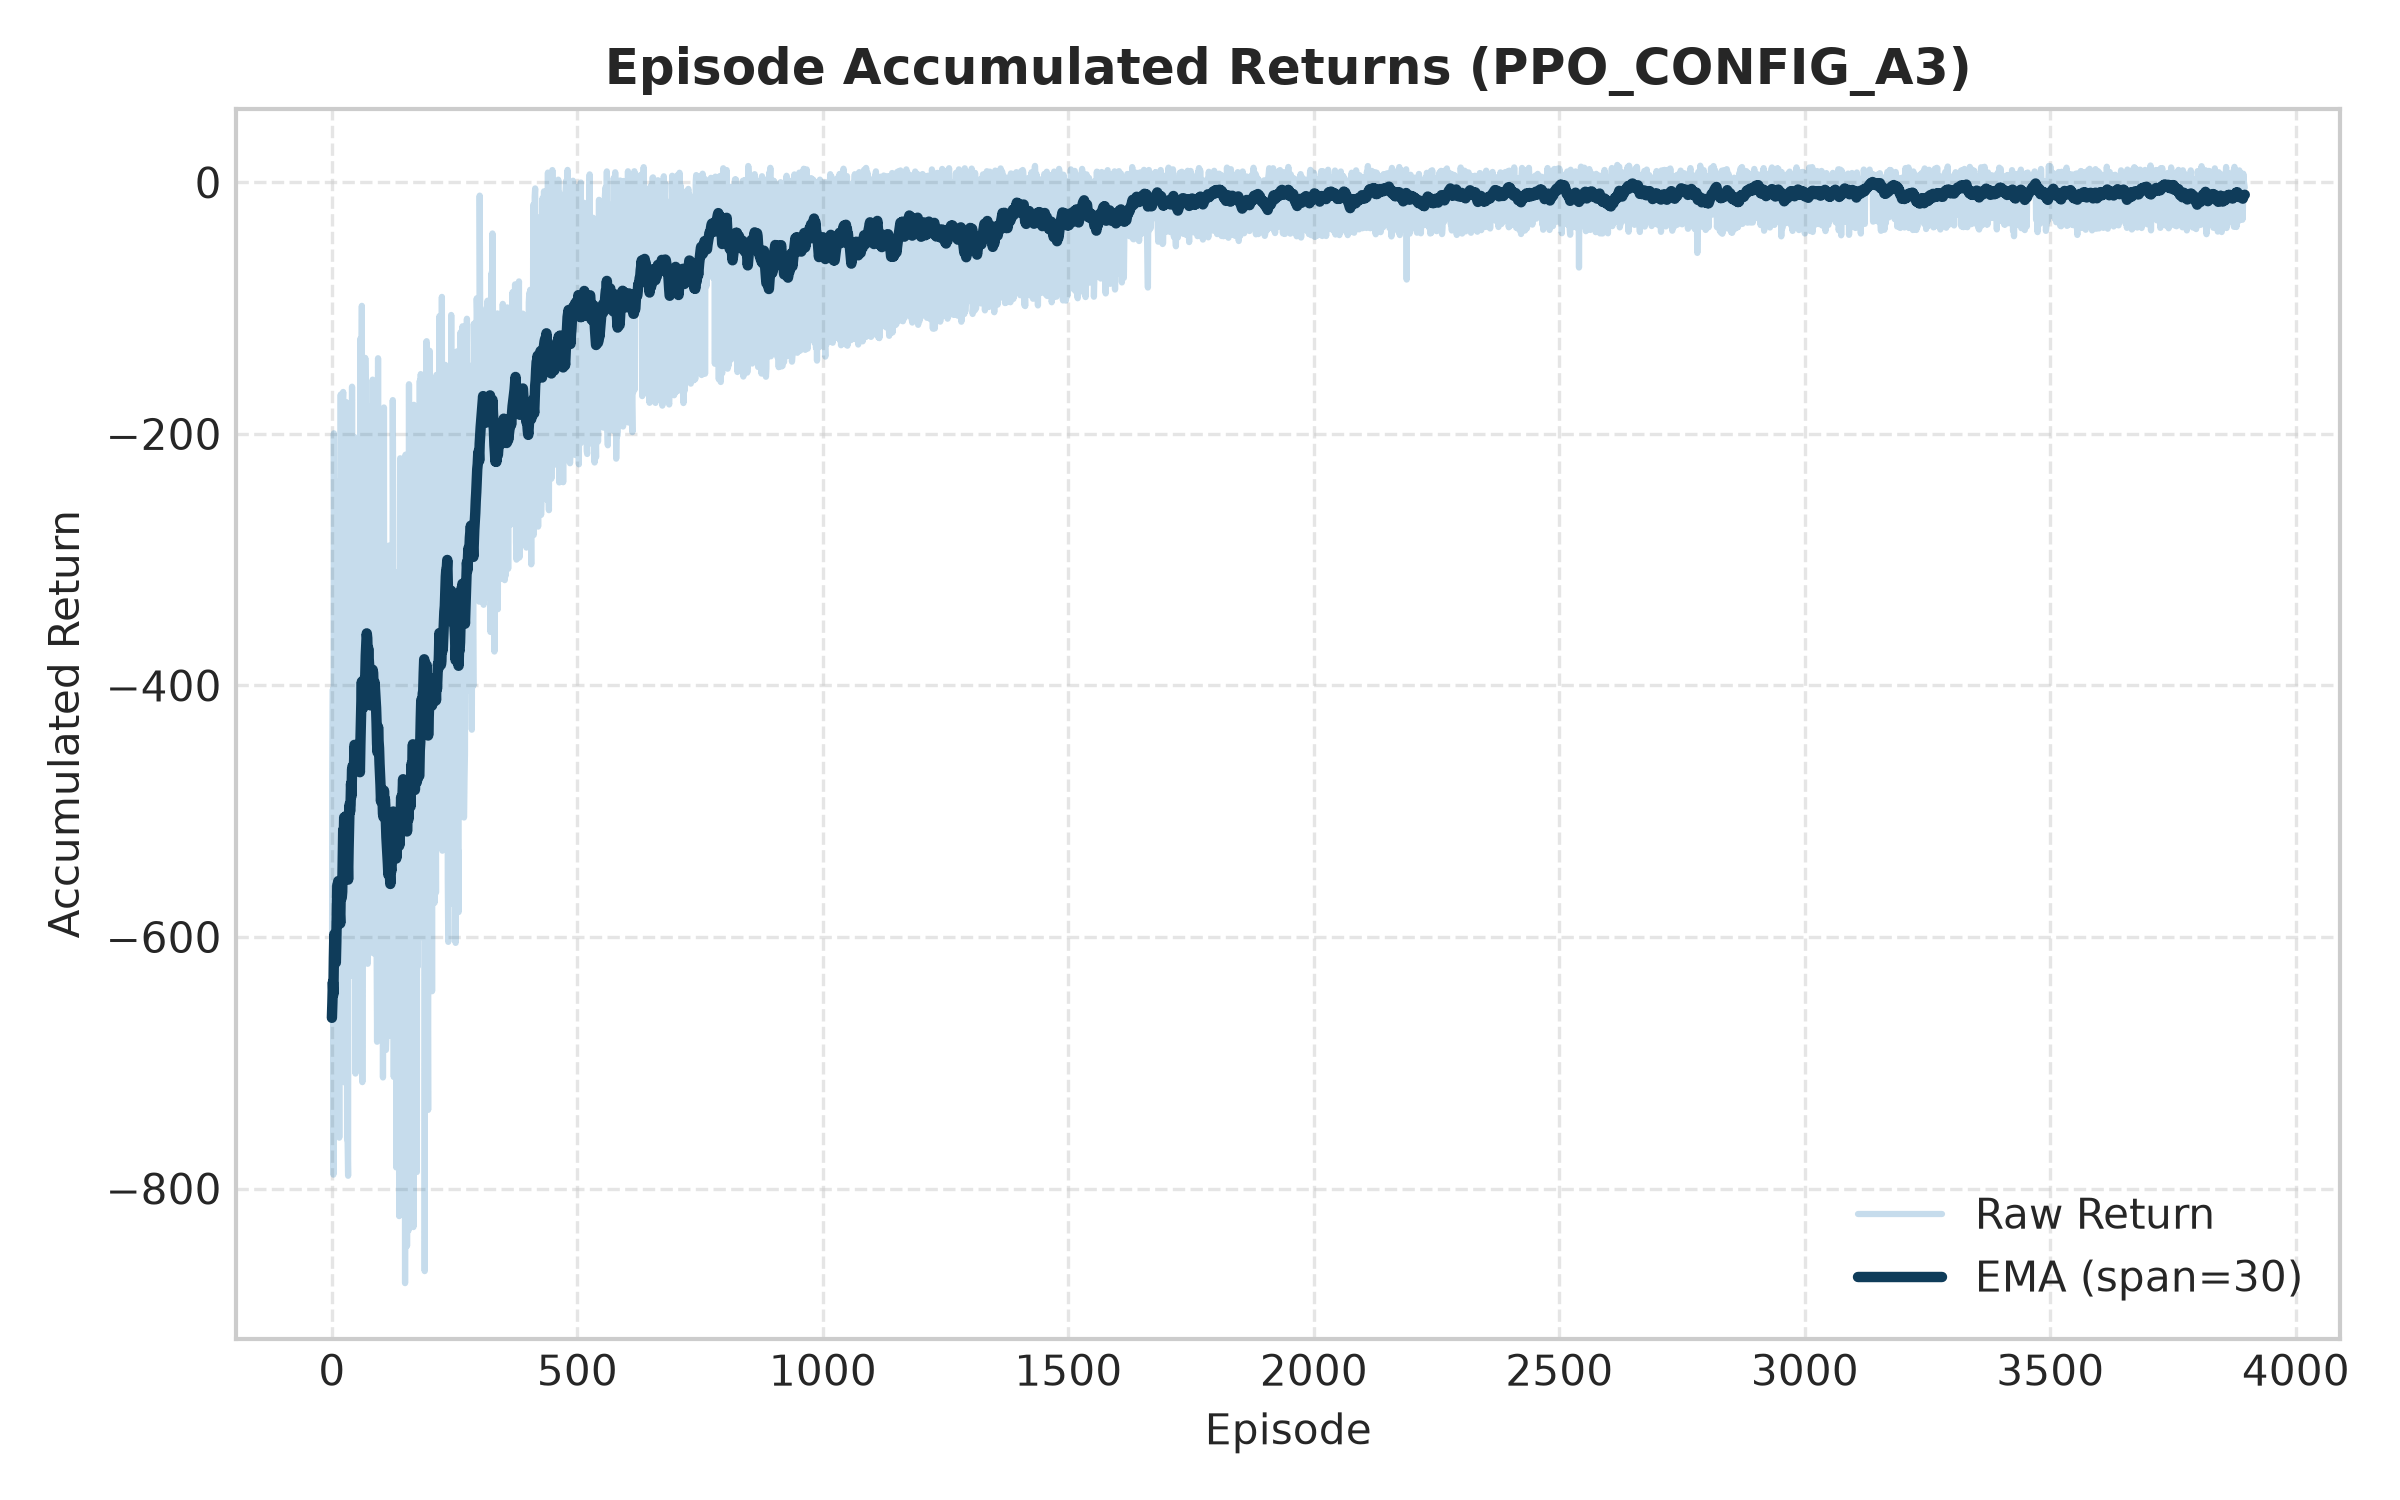

Displaying success_rate.png:


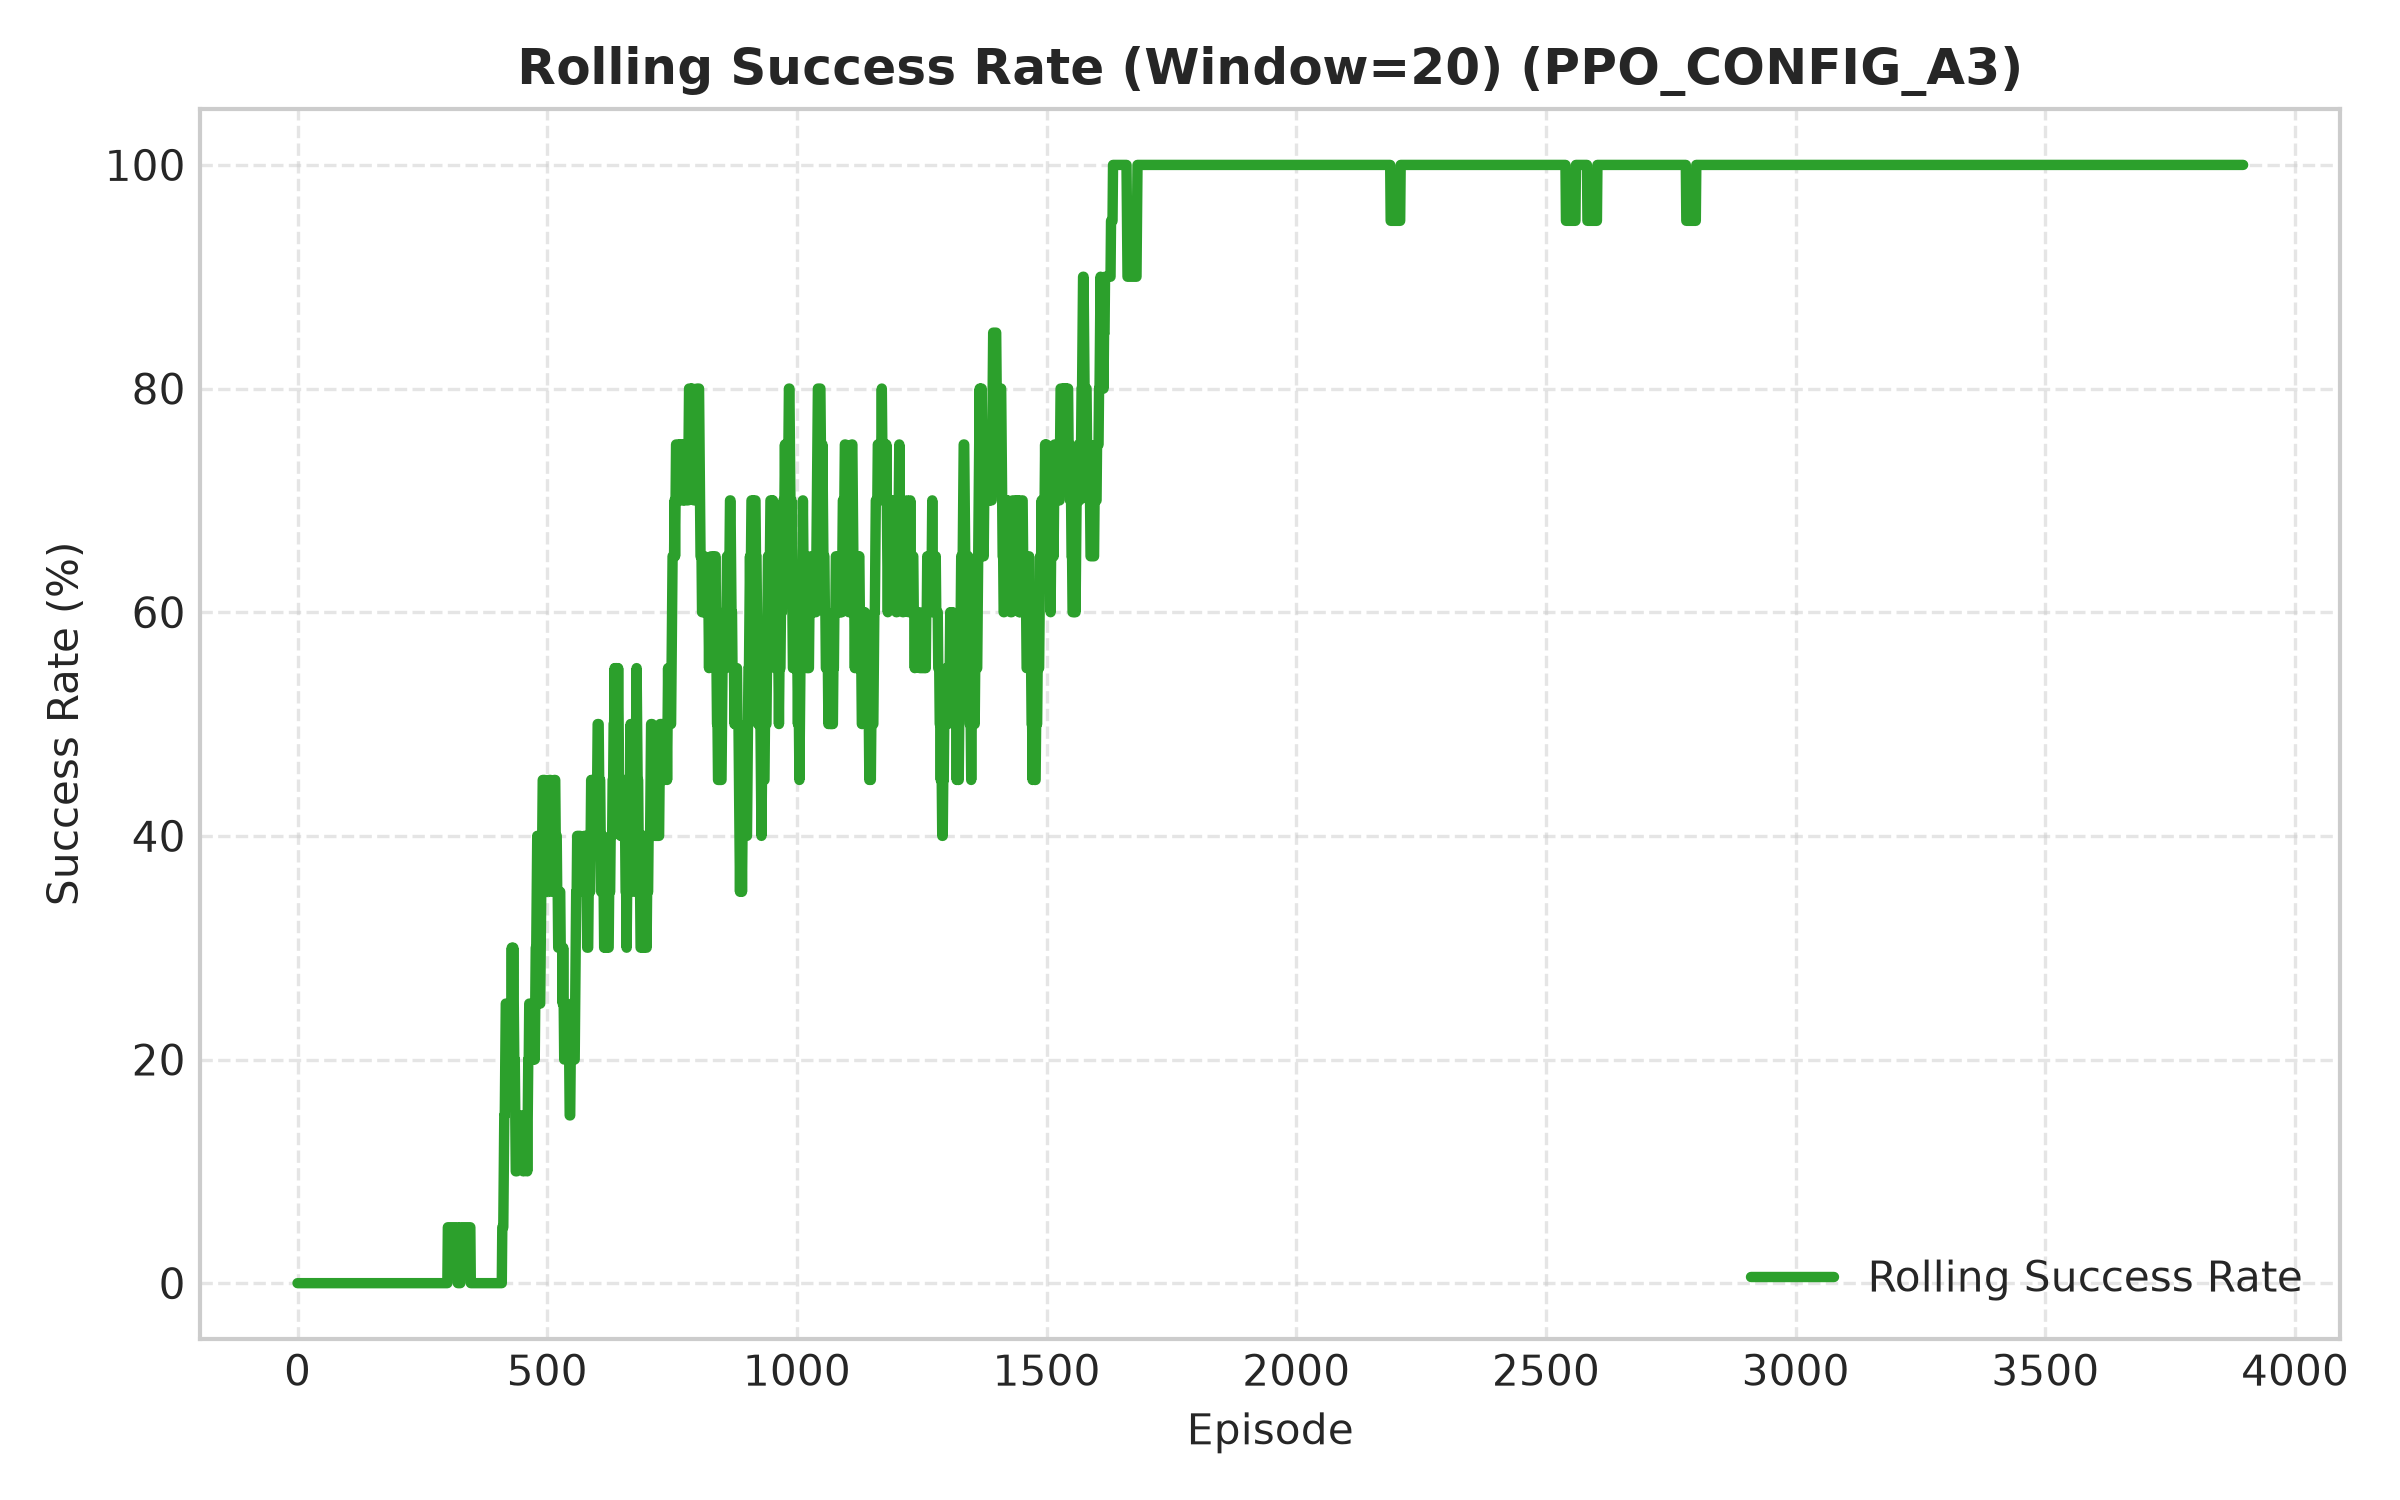

Displaying optimization_losses.png:


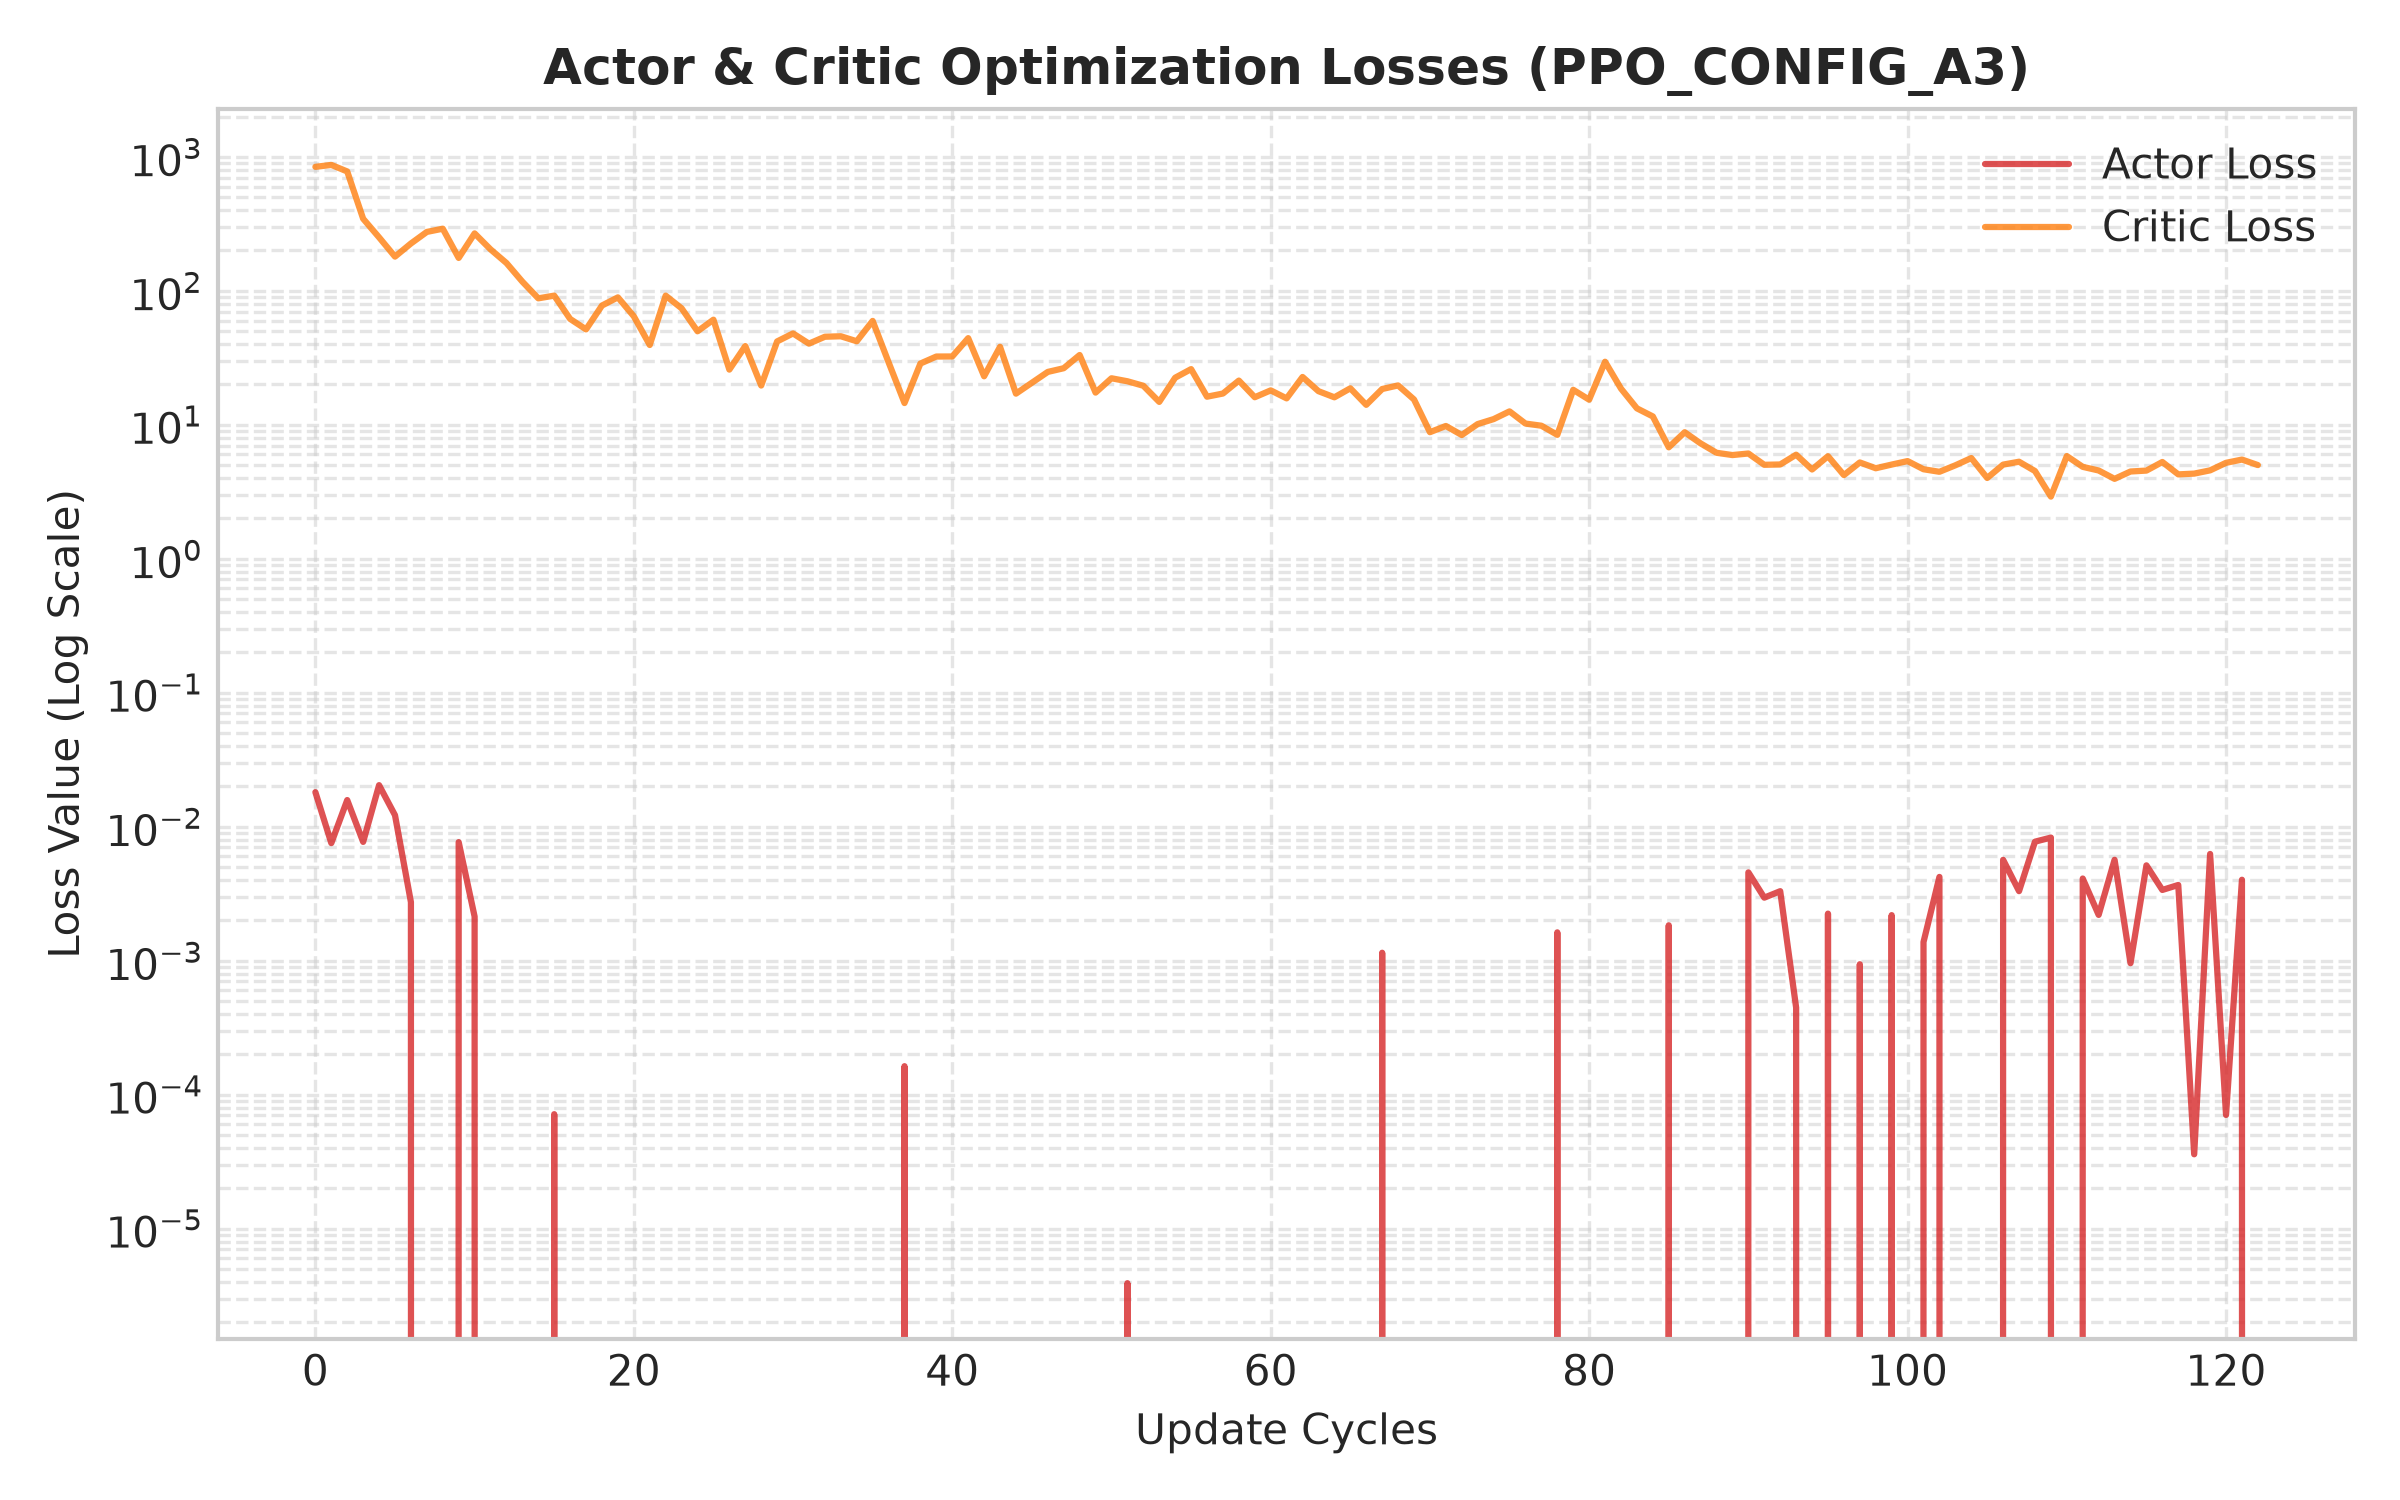

Displaying policy_entropy.png:


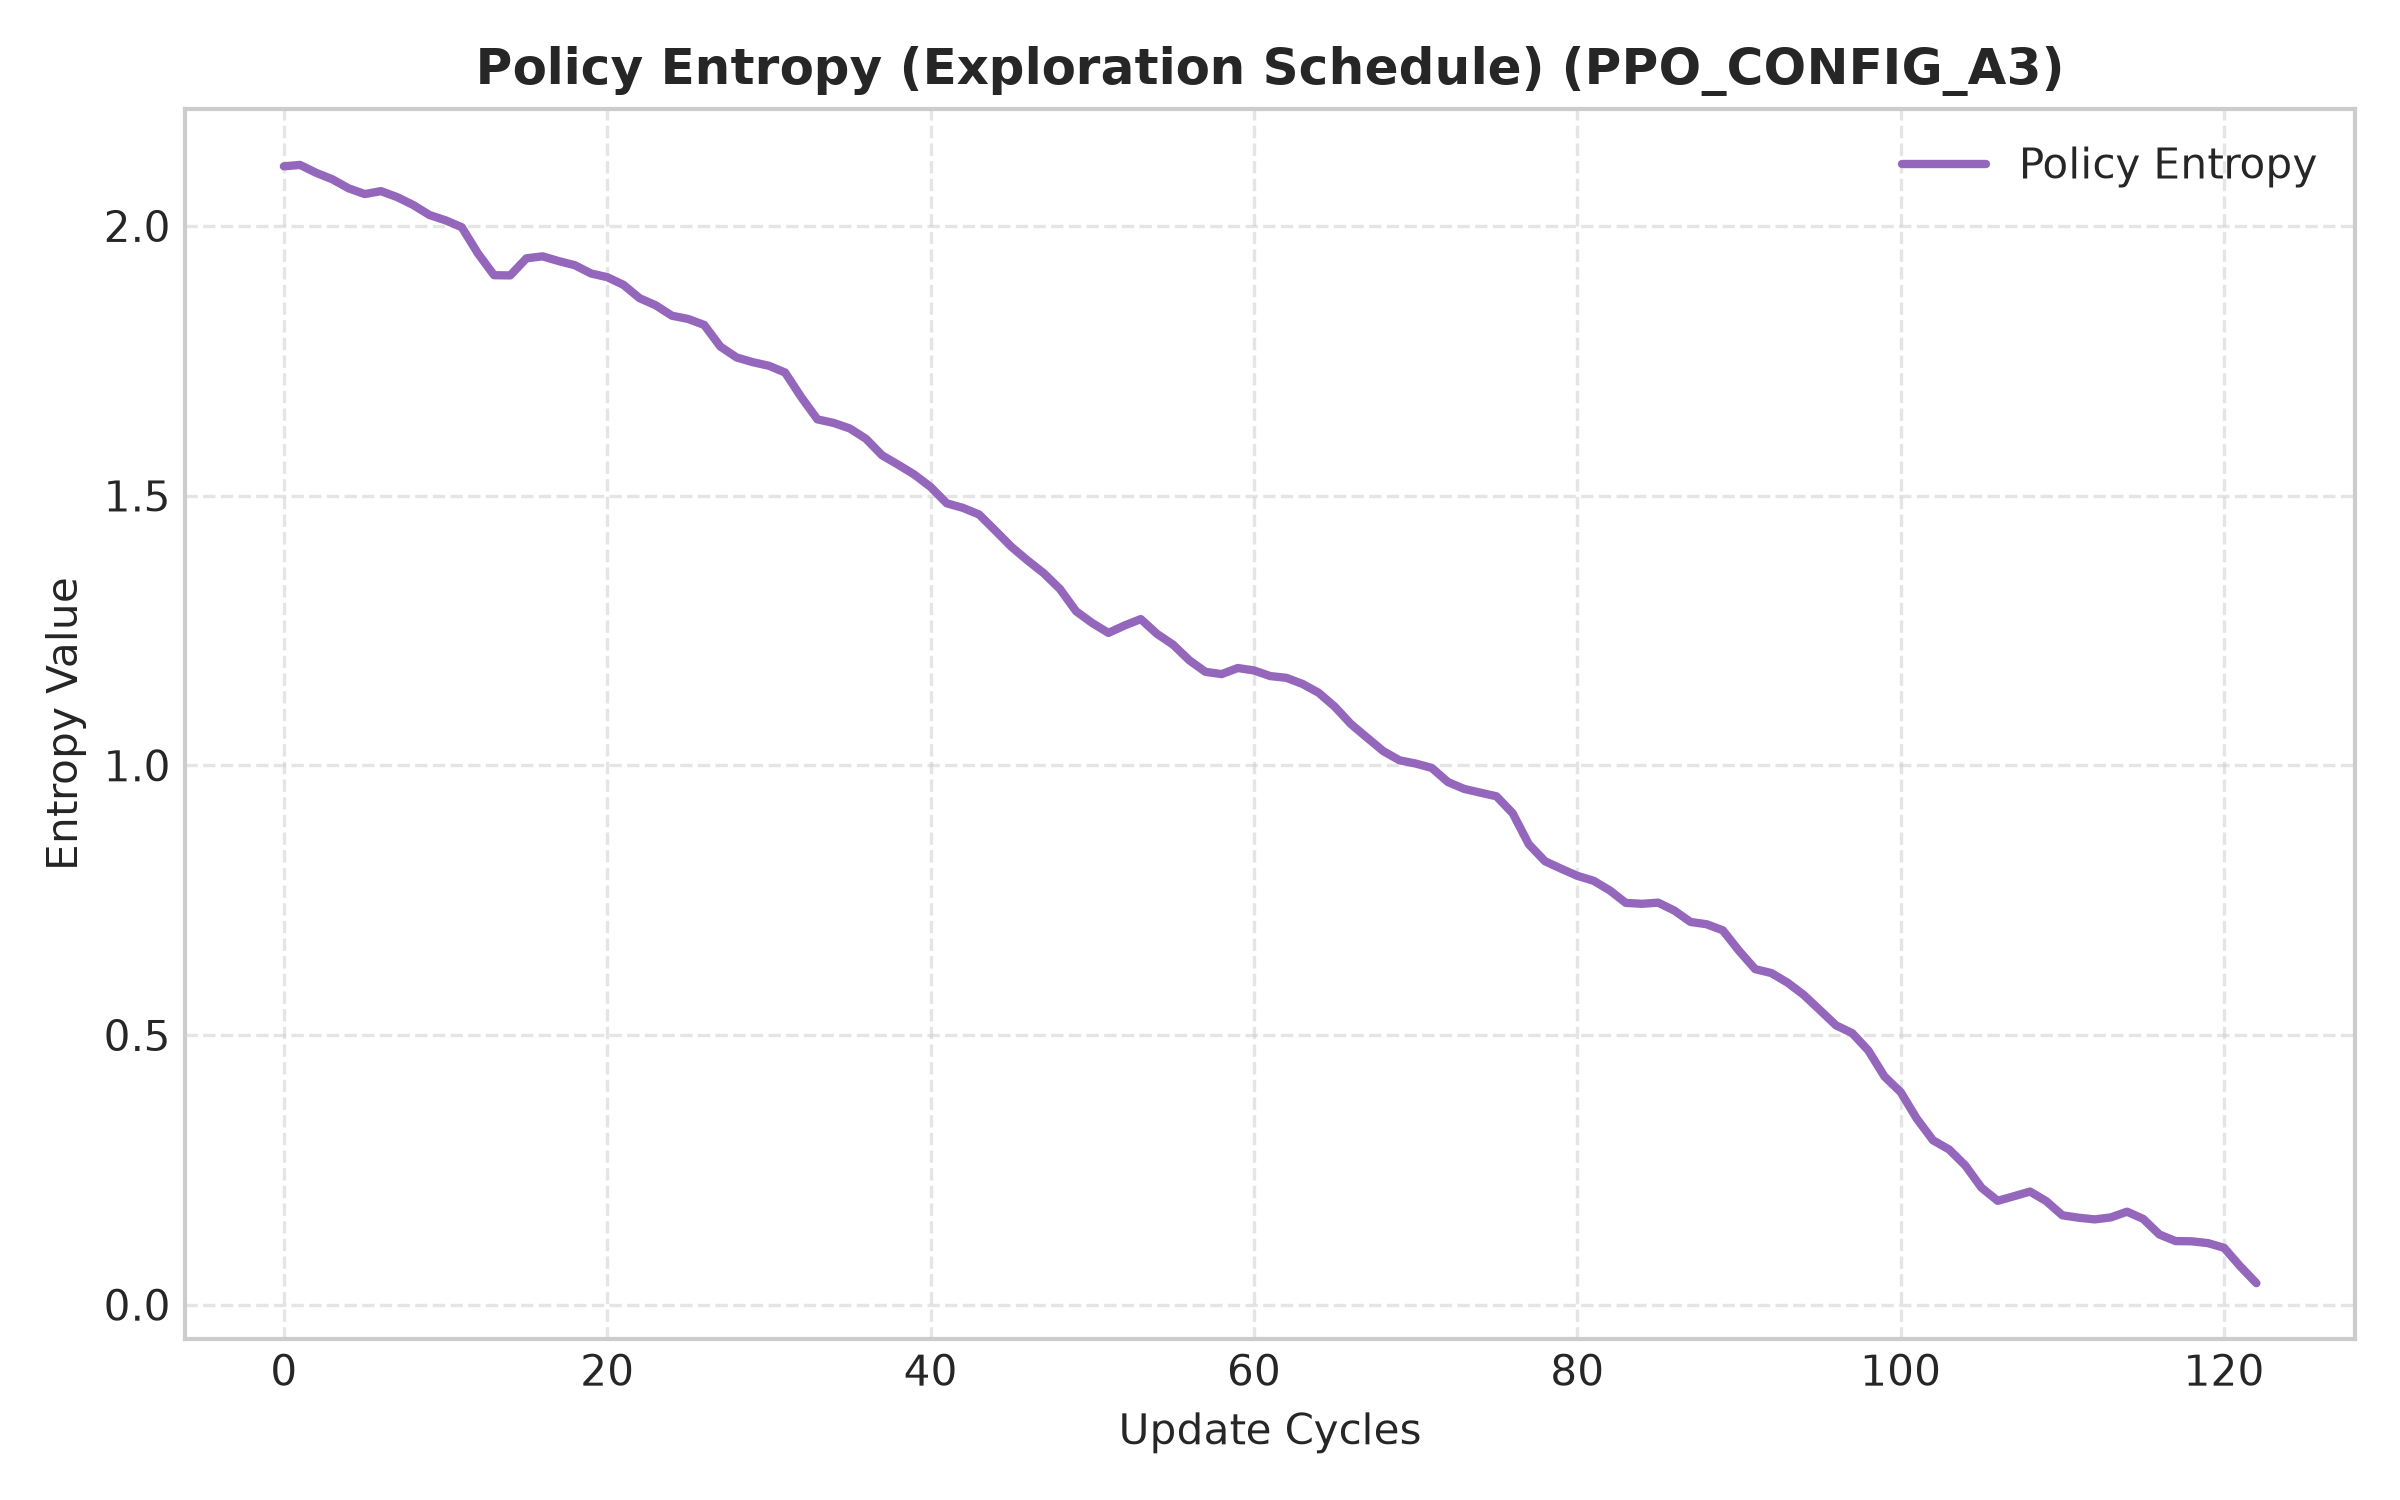

In [33]:
# 繪製與儲存四個獨立的訓練收斂圖表
!python src/Thumbs_Robot/plot_results.py --dir results/{CONFIG_NAME} --eval_csv results/{CONFIG_NAME}_evaluation/eval_results.csv

# 在 Notebook 中顯示產生的四個獨立訓練指標圖表
import os
from IPython.display import Image, display

img_dir = f"results/img/{CONFIG_NAME}"
plot_files = ["accumulated_returns.png", "success_rate.png", "optimization_losses.png", "policy_entropy.png"]

for plot_file in plot_files:
    plot_path = os.path.join(img_dir, plot_file)
    if os.path.exists(plot_path):
        print(f"Displaying {plot_file}:")
        display(Image(filename=plot_path))
    else:
        print(f"Warning: {plot_file} not found under {img_dir}. Check if plot_results.py ran successfully.")
